beta_analysis.ipynb, but for synthetic data

Set parameters

In [3]:
### INPUT DATA PARAMETERS ###
phase = 'p' 
# phase = 's' 
units = ['h', 'n']


paper_figure_dir = "/Users/ivandevert/Documents/papers/high_freq_ratio/paper_name_pre_submission/figs/"

# Beta computation params
stn_f_range = [2.5, 6.0]
dist_min = 0
dist_max = 100

### P-WAVE PARAMETERS ###
low_beta_window_p = [1, 5]
high_beta_window_p = [12, 20]
calib_mag_range_p = [1.0, 1.2]

### S-WAVE PARAMETERS ###
low_beta_window_s = [1, 5]
high_beta_window_s = [17, 25]
calib_mag_range_s = [1.4, 1.6]

# calibration event parameters
calib_rmax = 5.0
calib_zmax = 1.0
calib_stn_req = 3.0
ncalib_min = 10

# miscellaneous parameters
xsec_dmax = 1500
f_nyquist = 50.0

### UNOFFICIAL PARAMETERS ###
synthetic = True
logomega0_corr = 19.0
delsig_fixed = 3.0E6
delsig_scatter = 0
k = 0.38
Vs = 3464.0


# process some of the parameters
units = [el.upper() for el in units]

if phase == 'p':
    components = ['Z']
    calib_mag_range = calib_mag_range_p
    low_beta_window = low_beta_window_p
    high_beta_window = high_beta_window_p
elif phase == 's':
    components = ['N', 'E', '1', '2']

    calib_mag_range = calib_mag_range_s
    low_beta_window = low_beta_window_s
    high_beta_window = high_beta_window_s


In [4]:
# %matplotlib ipympl


import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import struct
import math
import time
import sys

sys.path.append('..')

import stressdrop_file_IO as sdio
import seismo_functions as sf
import mapping_tools as mt
import importlib
importlib.reload(sdio)
import obspy

from scipy import sparse
import utm
import copy 

import ipywidgets as widgets
from ipywidgets import interactive

from shapely.geometry import Point, MultiPoint
from shapely.geometry.polygon import Polygon

from lib.beta_functions import read_beta_files, read_betatxt_files, read_spec_df

from tqdm import trange


In [5]:

A =     np.array([4.33E5, 3.974E6])
Ap =    np.array([4.665E5, 3.938E6])

B =     np.array([4.40E5, 3.9343E6])
Bp =    np.array([4.60E5, 3.9543E6])

Define some functions

In [6]:

def get_colormap(d, cmap='coolwarm_r', method='percentile', **kwargs):

    d = d.astype(float)
    n = len(d)
    
    if method=='percentile':
        assert 'percentiles' in kwargs.keys(), "percentiles must be in kwargs"

        pct = kwargs['percentiles']

        d_sort = np.sort(d)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(d_sort[int(pct[0]*n)], d_sort[int(pct[1]*n)], 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    if method=='mediancenter':

        center = np.median(d)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        d_sort = np.sort(d)

        center_dists = np.array(center - d_sort[int(pct[0]*n)], 
                                d_sort[int(pct[1]*n)] - center)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(center-dist, center+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    if method=='logmediancenter':
        logd = np.log10(d)
        logcenter = np.median(logd)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        logd_sort = np.sort(logd)

        center_dists = np.array(logcenter - logd_sort[int(pct[0]*n)], 
                                logd_sort[int(pct[1]*n)] - logcenter)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.logspace(logcenter-dist, logcenter+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    return cmap, smap, norm



def p_norm(v, p):
    """Return the p-norm of a vector v (see ref. [2])

    Args:
        v (np.ndarray): array to calculate p-norm of
        p (int): p for p-norm

    Returns:
        float: p-norm of v
    """
    return np.power(np.sum(np.power(np.abs(v), p)), 1/p)

def model_p_norm(m, model_function, t, d, p):
    """Intermediate function for calculating the p-norm.

    Args:
        m (array-like): array of model parameters
        model_function (function): callable function
        t (np.ndarray): independent variable
        d (np.ndarray): data array
        p (int): p for p-norm

    Returns:
        float: p-norm of the residual (expected - observed) array
    """
    y = model_function(m, t)
    return p_norm(y - d, p)

def fit_p_norm(x, d, model, m0, p):
    """Find a fit to a model using scipy.optimize.minimize()

    Args:
        x (np.ndarray): independent variable
        d (np.ndarray): observations
        model (function): callable function, with inputs m (model 
            params) and x
        m0 (array-like): starting values for model parameters
        p (int): integer for choosing p-norm (1: L1-norm, 2: L2-norm, 
            etc.)

    Returns:
        np.ndarray: Best-fit model parameters
    """
    from scipy.optimize import minimize
    res = minimize(model_p_norm, m0, args=(model, x, d, p))
    return res.x

def line_model(m, x):
    """Slope-intercept form of a line.

    Args:
        m (array-like): (slope, intercept)
        x (np.ndarray): independent variable

    Returns:
        np.ndarray: y values on line
    """
    return m[0] * x + m[1]

def fit_line_p_norm(x, y, p):
    """Fit a simple line to x, y data using the p-norm.

    Args:
        x (np.ndarray): x values of data
        y (np.ndarray): y values of data
        p (np.ndarray): which norm to use to calculate the line 
            parameters. Least-squares when p==2.

    Returns:
        np.ndarray: (slope, intercept) of best-fit line.
    """
    m0 = np.polyfit(x, y, 1)
    return fit_p_norm(x, y, line_model, m0, p)

def compute_logbeta(spectra, low_f_ind, high_f_ind):
    # spectra is an (N x nf) array
    low_band = np.median(np.log10(spectra[:, low_f_ind[0]:low_f_ind[1]+1]), axis=1)
    high_band = np.median(np.log10(spectra[:, high_f_ind[0]:high_f_ind[1]+1]), axis=1)
    logbeta = high_band - low_band
    return logbeta

def boxplot(x, y, xbins, ax=None, color='r', **kwargs):

    if ax is None: ax = plt.gca()
    boxprops = dict(color=color)
    medianprops = dict(color=color, linewidth=2)
    whiskerprops = dict(color=color)
    capprops = dict(color=color)

    # toss out values of x, y where x is outside xbins bounds?
    
    inds = np.digitize(x, bins=xbins) - 1

    xmids = (xbins[1:] + xbins[:-1]) / 2

    xmids = xmids[np.unique(inds)]

    xwidth = xbins[1]-xbins[0]
    
    # get data in proper format for boxplot. This forms a sequence of 1D
    # arrays
    X = [y[inds==i] for i in np.unique(inds)]

    keys = kwargs.keys()
    if 'positions' not in keys: kwargs = {**kwargs, 'positions': xmids}
    if 'manage_ticks' not in keys: kwargs = {**kwargs, 'manage_ticks': False}
    if 'widths' not in keys: kwargs = {**kwargs, 'widths': xwidth*0.8}
    if 'sym' not in keys: kwargs = {**kwargs, 'sym': ''}
    if 'whis' not in keys: kwargs = {**kwargs, 'whis': (5, 95)}

    if 'boxprops' not in keys: kwargs = {**kwargs, 'boxprops': boxprops}
    if 'medianprops' not in keys: kwargs = {**kwargs, 'medianprops': medianprops}
    if 'whiskerprops' not in keys: kwargs = {**kwargs, 'whiskerprops': whiskerprops}
    if 'capprops' not in keys: kwargs = {**kwargs, 'capprops': capprops}

    out = ax.boxplot(X, **kwargs)

    return out

def compute_stn(signal_spectra, noise_spectra, stn_inds):
    # signal_spectra and noise_spectra are (N x nf) 2D-arrays
    signal = np.median(signal_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    noise = np.median(noise_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    stn = signal / noise
    return stn

def get_cha(stname):
    return stname.split('.')[-1]

def get_component(cha):
    return cha[-1]

def get_units(cha):
    return cha[-2]

def get_sdir(stname):
    if stname[-1] in ['1', 'Z']:
        return 'V'
    elif stname[-1] in ['2', '3', 'N', 'E']:
        return 'H'
    else:
        raise ValueError(f"Unknown component: {stname[-1]}")

def get_brune_model(omega0, fc, f):
    """Returns a Brune model for a given omega0 and corner frequency. 
    Output scale is amplitude, not log amplitude.

    Args:
        omega0 (float): Omega0 parameter (scales with moment)
        fc (float): Corner frequency
        f (np.ndarray): Frequency array

    Returns:
        brune: Brune model

    Sources:

    Last Modified:
        2023-08-17
    """
    brune = omega0 / (1 + np.power(f/fc, 2))
    return brune

In [7]:
def distance(s_lat, s_lng, e_lat, e_lng):

   # Approximate radius of earth in km
   R = 6373.0

   s_lat = s_lat*np.pi/180.0
   s_lng = np.deg2rad(s_lng)
   e_lat = np.deg2rad(e_lat)
   e_lng = np.deg2rad(e_lng)

   d = np.sin((e_lat - s_lat)/2)**2 + np.cos(s_lat)*np.cos(e_lat) * np.sin((e_lng - s_lng)/2)**2

   return 2 * R * np.arcsin(np.sqrt(d))

In [8]:
df_real = pd.read_csv("/Users/ivandevert/projects/ridgecrest2019_prev/res/event_catalog.txt", sep='\s+')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_3007/311331351.py:1: SyntaxWarning: invalid escape sequence '\s'
  df_real = pd.read_csv("/Users/ivandevert/projects/ridgecrest2019_prev/res/event_catalog.txt", sep='\s+')


In [9]:
df_real

,event_id,origin_time,mag,mag_type,longitude,latitude,depth,Mw
0,17850492,2019-07-04T20:32:34.300000,2.05,Ml,-117.554167,35.638833,6.44,-9.0
1,37218988,2019-07-04T17:35:52.160000,3.00,Mh,-117.502667,35.689667,1.18,-9.0
2,37218996,2019-07-04T17:37:25.670000,3.00,Mh,-117.452500,35.678500,15.76,-9.0
3,37219156,2019-07-06T03:22:48.300000,4.64,Mlr,-117.736500,35.891000,9.10,-9.0
4,37219164,2019-07-06T03:23:50.720000,4.84,Mlr,-117.617833,35.803167,11.44,-9.0
...,...,...,...,...,...,...,...,...
14916,38592279,2019-07-17T23:48:57.310000,1.55,Ml,-117.404667,35.616333,5.17,-9.0
14917,38592287,2019-07-17T23:50:48.780000,1.98,Ml,-117.605500,35.786667,2.63,-9.0
14918,38592327,2019-07-17T23:57:22.260000,1.75,Ml,-117.446833,35.626333,4.47,-9.0
14919,38592335,2019-07-17T23:58:45.980000,1.22,Ml,-117.686833,35.929000,1.48,-9.0


In [10]:
# synthetic data parameters
nevents = 15000
nstations = 250
qlat_range = [35.5, 36.0]
qlon_range = [-117.75, -117.34]
qdep_range = [0, 20.0]
qmag_range = [1, 7.1]
slat_range = [34.5, 37.0]
slon_range = [-119.0, -116.3]
selev_range = [0, 500]

# set the random seed
rng = np.random.default_rng(42)

# generate event-specific data using the above ranges
event_id = np.arange(1000000, 1000000+nevents)
qlat = rng.uniform(qlat_range[0], qlat_range[1], nevents)
qlon = rng.uniform(qlon_range[0], qlon_range[1], nevents)
qdep = rng.uniform(qdep_range[0], qdep_range[1], nevents)

# qmag = rng.uniform(qmag_range[0], qmag_range[1], nevents)
qmag_possibilities = np.arange(qmag_range[0], qmag_range[1], 0.001)

qmag_a = 5.0
qmag_b = 0.9
qmag_possibilities = np.arange(qmag_range[0], qmag_range[1] + 0.002, 0.001)
qmag_probabilities = 10**(qmag_a - qmag_b * qmag_possibilities)
qmag_probabilities = qmag_probabilities / sum(qmag_probabilities)
qmag = rng.choice(qmag_possibilities, nevents, p=qmag_probabilities)

delsig_scatter = np.ones(nevents)
delsig_scatter = np.random.lognormal(0, 0.473, nevents) # 0.473 is the std of real data

delsig = delsig_fixed * delsig_scatter

# generate station-specific data using the above ranges
slat = rng.uniform(slat_range[0], slat_range[1], nstations)
slon = rng.uniform(slon_range[0], slon_range[1], nstations)
selev = rng.uniform(selev_range[0], selev_range[1], nstations)
stid = np.arange(0, nstations)
chnames = [str(el) for el in stid]
station_names = np.array([".".join(["SN", f"{el.zfill(3)}", "", f"HH{components[0]}"]) for el in chnames])

d = [[]] * nevents

nf = 65
f = np.linspace(0, f_nyquist, nf)

for i in trange(nevents):

    # for each event, choose 100 random unique stations
    stn_inds = rng.choice(nstations, 100, replace=False)

    # compute distance between event and station
    dists = distance(qlat[i], qlon[i], slat[stn_inds], slon[stn_inds])

    M0_syn = np.power(10, (1.5 * qmag[i] + 9.1))

    # add some scatter to delsig
    logomega0_syn = np.log10(M0_syn) - logomega0_corr

    # estimate fc given Mw_syn and assuming self-similarity
    fc_syn = np.power((16/7.0) * ((delsig[i])/M0_syn), 1/3.0) * k * Vs
    brunes = np.tile((np.power(10, logomega0_syn) / (1 + np.power(f[:, np.newaxis]/fc_syn, 2))), 100).T
    

    df_ev = pd.DataFrame({
        "event_id": event_id[i],
        "qlat": qlat[i],
        "qlon": qlon[i],
        "qdep": qdep[i],
        "qmag": qmag[i],
        "stname": station_names[stn_inds],
        "slat": slat[stn_inds],
        "slon": slon[stn_inds],
        "selev": selev[stn_inds],
        "deldist": dists,
        "delsig": delsig[i],
        "fc": fc_syn,
        "s2": list(brunes)
    })

    # df_ev['s2'] = list(brunes)

    d[i] = df_ev


ev_dep = ['event_id', 'qlat', 'qlon', 'qdep', 'qmag', 'delsig', 'fc']
st_dep = ['stname', 'slat', 'slon', 'selev']
dependents = ['deldist', 's2']

df_all = pd.concat(d).reset_index(inplace=False, drop=True)
df_ev = df_all.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)


100%|██████████| 15000/15000 [00:11<00:00, 1258.30it/s]


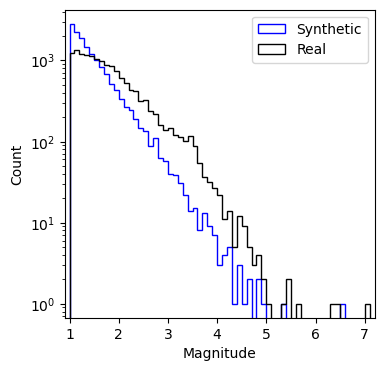

In [11]:
plt.figure(figsize=(4,4))
plt.hist(qmag, bins=np.arange(qmag_range[0], qmag_range[1], 0.1), histtype='step', color='b', log=True, label="Synthetic")
plt.hist(df_real['mag'].values, bins=np.arange(qmag_range[0], 7.5, 0.1), histtype='step', color='k', log=True, label="Real")
plt.xlabel("Magnitude")
plt.ylabel("Count")
# plt.title(f"n = {nevents:,}")
plt.xlim((0.9, 7.2))
plt.legend()
plt.savefig(paper_figure_dir + "hist.pdf", bbox_inches='tight')
plt.show()

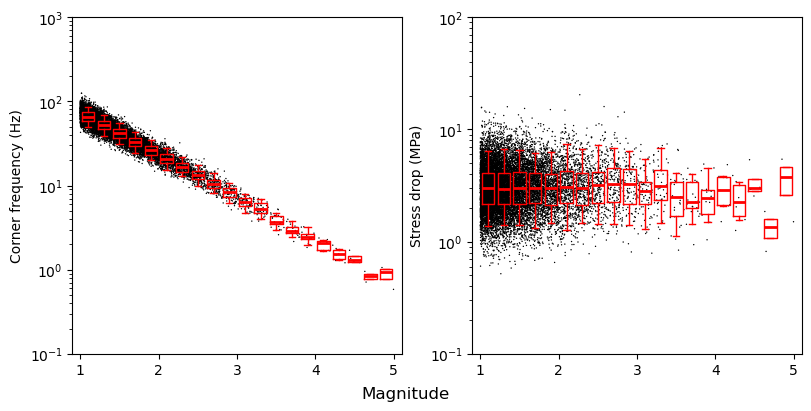

In [12]:

dx = 0.2
edges = np.arange(1.0, 7.3, dx)


fig, axs = plt.subplots(1,2, figsize=(8,4), layout='constrained', sharex=True)

axs[0].scatter(df_ev['qmag'], df_ev['fc'], c='k', s=1, edgecolors='none')
axs[1].scatter(df_ev['qmag'], df_ev['delsig']/1E6, c='k', s=1, edgecolors='none')

boxplot(df_ev['qmag'], df_ev['fc'], xbins=edges, ax=axs[0], color='r')
boxplot(df_ev['qmag'], df_ev['delsig']/1E6, xbins=edges, ax=axs[1], color='r')

axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_ylabel('Corner frequency (Hz)')
axs[1].set_ylabel('Stress drop (MPa)')

axs[0].set_xlim([0.9,5.1])
axs[0].set_ylim([1E-1, 1E3])

axs[1].set_ylim([1E-1, 1E2])

fig.supxlabel('Magnitude')


plt.savefig(paper_figure_dir + "syn_source_params.pdf", bbox_inches='tight')
plt.show()



In [13]:
# Print out frequency information

nf = len(df_all.loc[0, 's2'])

f = np.linspace(0, f_nyquist, nf)
dfreq = f[1] - f[0]


# calculate actual indices and bands for beta computation
low_beta_window_inds = np.array([np.argmin(np.abs(f - el)) for el in low_beta_window])
high_beta_window_inds = np.array([np.argmin(np.abs(f - el)) for el in high_beta_window])

low_beta_band = [f[low_beta_window_inds[0]], f[low_beta_window_inds[1]]]
high_beta_band = [f[high_beta_window_inds[0]], f[high_beta_window_inds[1]]]


# calculate actual indices and bands for STN computations
stn_inds = [np.argmin(np.abs(f - el)) for el in stn_f_range]

stn_band = [f[stn_inds[0]], f[stn_inds[1]]]


print("")
print("FREQUENCY ARRAY INFORMATION")
print("----------------------------")
print(f"Frequency array ranges from {f[0]:.2f} to {f[-1]:.2f} Hz with {len(f)} elements (df = {dfreq:.3f} Hz). ")
print(f"Desired | Actual low-frequency band:   {low_beta_window[0]:7.3f} -{low_beta_window[1]:7.3f} Hz | {low_beta_band[0]:7.3f} -{low_beta_band[1]:7.3f} Hz")
print(f"Desired | Actual high-frequency band:  {high_beta_window[0]:7.3f} -{high_beta_window[1]:7.3f} Hz | {high_beta_band[0]:7.3f} -{high_beta_band[1]:7.3f} Hz")
print(f"Desired | Actual signal-to-noise band: {stn_f_range[0]:7.3f} -{stn_f_range[1]:7.3f} Hz | {stn_band[0]:7.3f} -{stn_band[1]:7.3f} Hz")



FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 65 elements (df = 0.781 Hz). 
Desired | Actual low-frequency band:     1.000 -  5.000 Hz |   0.781 -  4.688 Hz
Desired | Actual high-frequency band:   12.000 - 20.000 Hz |  11.719 - 20.312 Hz
Desired | Actual signal-to-noise band:   2.500 -  6.000 Hz |   2.344 -  6.250 Hz


Load data, index events and stations, and filter out bad results. This is to setup for the inverse problem.

In [14]:


# These are columns that are station-dependent, event-dependent, and 
# both-dependent. pandas pivot_table might be useful here
st_dep = ['stname', 'slat', 'slon', 'selev']
ev_dep = ['event_id', 'qmag', "qlon", "qlat", "qdep", 'delsig']
dependents = ['deldist', 's2', 'logbeta']

print("-----------------------------")
print("---    DATA PROCESSING    ---")
print("-----------------------------")
    
print("\nFiltering out records based on user-specified criteria...")
print("---------------------------------------------------------")

# df/df_all has one row per station-event pair
df = df_all.copy()
df = df.rename(columns={"stid":"stname"})

# df = df.drop(columns=['nts_p', 'nts_s'])

# get initial number of records
npairs_initial = len(df)
nevents_initial = len(np.unique(df['event_id']))
nstations_initial = len(np.unique(df['stname']))
print(f"{npairs_initial:,.0f} records in total. {nevents_initial:,.0f} events, {nstations_initial:,.0f} stations.")

# remove events below the lower calibration event magnitude, since these are unused for all future steps
t0 = time.time()
df = df[df['qmag'] >= calib_mag_range[0]].reset_index(drop=True)
npairs = len(df)
print(f"{npairs_initial - npairs:,.0f} pairs with qmag < M{calib_mag_range[0]:.2} removed (t = {time.time()-t0:.3f} s). {len(df):,.0f} remaining.")

# remove distant event-station records
t0 = time.time()
df = df[df['deldist'] <= dist_max].reset_index(drop=True)
print(f"{npairs - len(df):,.0f} pairs with deldist > {dist_max} removed (t = {time.time()-t0:.3f} s). {len(df):,.0f} remaining.")

# get cha, component, and unit columns
t0 = time.time()
df['cha'] = df['stname'].apply(get_cha)
df['component'] = df['cha'].apply(get_component)
df['unit'] = df['cha'].apply(get_units)
print(f"Computed cha, component, and unit columns (t = {time.time()-t0:.2} s). {len(df):,.0f} remaining.")

# remove components not in 'components' object ('N', 'E', 'Z', for example)
t0 = time.time()
l1 = len(df)
nstations = len(np.unique(df['stname']))
df = df[np.any([df['component'].values==el for el in components], axis=0)].reset_index(drop=True)
print(f"{l1-len(df):,.0f} records, {nstations-len(np.unique(df['stname']))} stations removed (component not in {components}) (t = {time.time()-t0:.2} s). {len(df):,.0f} remaining.")

# add a column 'sdir' for direction, either 'H' or 'V', for horizontal or 
# vertical, based on the last character of the stname. 'N', 'E', '2', and '3'
# should be horizontal, '1' and 'Z' should be vertical


# t0 = time.time()
# df['sdir'] = df['stname'].apply(get_sdir)
# print(f"Computed sdir column (t = {time.time()-t0:.2} s). {len(df[df['sdir']=='H']):,.0f} horizontal, {len(df[df['sdir']=='V']):,.0f} vertical records")
# st_dep += ['sdir']

nevents = len(np.unique(df['event_id']))
nstations = len(np.unique(df['stname']))
print(f"{nevents:,.0f} events remaining, {nstations:,.0f} stations remaining.")

# remove units not in 'unit' object ('H', 'N', for example)
t0 = time.time()
l1 = len(df)
df = df[np.any([df['unit'].values==el for el in units], axis=0)].reset_index(drop=True)
print(f"{l1-len(df):,.0f} records removed (unit not in {units}) (t = {time.time()-t0:.2} s). {len(df):,.0f} remaining.")

# drop these columns
df = df.drop(columns=['cha', 'component', 'unit']).reset_index(drop=True)

# # # explode!
df['event_id'] = df['event_id'].astype(int)
df['qmag'] = df['qmag'].astype(float)
df['qlat'] = df['qlat'].astype(float)
df['qlon'] = df['qlon'].astype(float)
df['qdep'] = df['qdep'].astype(float)
df['slat'] = df['slat'].astype(float)
df['slon'] = df['slon'].astype(float)
df['selev'] = df['selev'].astype(float)
df['deldist'] = df['deldist'].astype(float)
# df['nts'] = df['nts'].astype(float)
df['delsig'] = df['delsig'].astype(float)

df['logbeta'] = np.nan

# Compute sx and sy (station easting and northing)
t0 = time.time()
df['sx'], df['sy'], zn, zl = utm.from_latlon(
    df['slat'].values, 
    df['slon'].values
    )
st_dep += ['sx', 'sy']
df.reset_index(drop=True, inplace=True)

# Compute qxs and qys of events (event eastings and northings)
df['qx'], df['qy'], zn, zl = utm.from_latlon(
    df['qlat'].values, 
    df['qlon'].values
    )
ev_dep += ['qx', 'qy']
df.reset_index(drop=True, inplace=True)
print(f"Earthquake and station eastings and westings computed (t = {time.time()-t0:.3f} s)")

# # make sure each earthquake has enough remaining records
# df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)
# df_ev = df_ev[df_ev['stname'].map(len) >= nrecords_min].reset_index(drop=True)
# print(f"{int(nevents_initial-len(df_ev))} events removed due to not enough"
#     f" records (needs >= {nrecords_min})")

# group by station in df_sta and add 'stind' column, unique for each station
t0 = time.time()
df_sta = df.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)
df_sta['stind'] = df_sta.index.values.astype(int)
st_dep += ['stind']
print(f"Grouped by station (t = {time.time()-t0:.3f} s). {len(df_sta):,.0f} stations remaining.")

t0 = time.time()
df = df_sta.explode(ev_dep + dependents)
df.reset_index(drop=True, inplace=True)
print(f"Exploded (t = {time.time()-t0:.3f} s)")

df['event_id'] = df['event_id'].astype(int)
df['qmag'] = df['qmag'].astype(float)
df['qlat'] = df['qlat'].astype(float)
df['qlon'] = df['qlon'].astype(float)
df['qdep'] = df['qdep'].astype(float)
df['slat'] = df['slat'].astype(float)
df['slon'] = df['slon'].astype(float)
df['selev'] = df['selev'].astype(float)
df['deldist'] = df['deldist'].astype(float)
# df['nts_p'] = df['nts_p'].astype(float)
# df['nts_s'] = df['nts_s'].astype(float)
df['qx'] = df['qx'].astype(float)
df['qy'] = df['qy'].astype(float)
df['sx'] = df['sx'].astype(float)
df['sy'] = df['sy'].astype(float)
df['delsig'] = df['delsig'].astype(float)
df['logbeta'] = df['logbeta'].astype(float)

# save the events within calibration M range for later
df_calib = df[np.logical_and(df['qmag'] >= calib_mag_range[0], df['qmag'] < calib_mag_range[1])].reset_index(drop=True)

# group by event
df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)

# get a list of event ids that are in df['event_id'] but not in df_ev['event_id'] 
absent = df[~df['event_id'].isin(df_ev['event_id'])].reset_index(drop=True)

assert nevents-len(df_ev)==0, 'Uh oh: missing events'
assert len(np.unique(absent['event_id']))==0, 'Uh oh: missing events'

# nevents = len(np.unique(df['event_id']))
# evs1 = df.copy()
# nstations = len(np.unique(df['stname']))
# print(f"{nevents:,.0f} events remaining, {nstations:,.0f} stations remaining.")


nevents = len(df_ev)
nstations = len(df_sta)
ndata = len(df)

print("-------------")
print("Final counts:")
print("-------------")
print(f"{nevents:,.0f} of {nevents_initial:,.0f} events ({nevents/nevents_initial*100:.1f}%)")
print(f"{nstations:,.0f} of {nstations_initial:,.0f} stations ({nstations/nstations_initial*100:.1f}%)")
print(f"{ndata:,.0f} of {npairs_initial:,.0f} records ({ndata/npairs_initial*100:.1f}%)")
print("")
print("Calibration events:")
print("-------------------")
print(f"{len(df_calib):,.0f} records of {len(np.unique(df_calib['event_id'])):,.0f} events between M {calib_mag_range[0]:.2f} and {calib_mag_range[1]:.2f}")


-----------------------------
---    DATA PROCESSING    ---
-----------------------------

Filtering out records based on user-specified criteria...
---------------------------------------------------------
1,500,000 records in total. 15,000 events, 250 stations.
0 pairs with qmag < M1.0 removed (t = 0.367 s). 1,500,000 remaining.
821,572 pairs with deldist > 100 removed (t = 0.283 s). 678,428 remaining.
Computed cha, component, and unit columns (t = 0.51 s). 678,428 remaining.
0 records, 0 stations removed (component not in ['Z']) (t = 2.9 s). 678,428 remaining.
15,000 events remaining, 195 stations remaining.
0 records removed (unit not in ['H', 'N']) (t = 0.15 s). 678,428 remaining.
Earthquake and station eastings and westings computed (t = 0.290 s)
Grouped by station (t = 1.202 s). 195 stations remaining.
Exploded (t = 0.661 s)
-------------
Final counts:
-------------
15,000 of 15,000 events (100.0%)
195 of 250 stations (78.0%)
678,428 of 1,500,000 records (45.2%)

Calibration eve

In [15]:
## Compute logbeta values for spectra

spec_inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]

# compute logbeta for spectra
print("Computing logbeta for spectra...", end='')
t0 = time.time()
s2 = np.vstack(df['s2'].values[spec_inds], dtype=float)

logbeta = compute_logbeta(s2, low_beta_window_inds, high_beta_window_inds)
df['logbeta'] = np.nan
df.loc[spec_inds, 'logbeta'] = logbeta
print(f"done (t = {time.time()-t0:.3f} s)")

dependents += ['logbeta']

Computing logbeta for spectra...done (t = 3.295 s)


In [16]:
## Compute STN values for spectra

# find indices where spectra are non-NaN, stack into 2D-array
# should get equivalent result using either p1 or p2 columns
print("Computing STN for spectra...", end='')
t0 = time.time()


if synthetic:
    df['stn'] = 100.0
else:
    spec_inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]
    s2 = np.vstack(df['s2'].values[spec_inds], dtype=float)
    s1 = np.vstack(df['s1'].values[spec_inds], dtype=float)
    # compute stn for each row in the 2D-array
    stn = compute_stn(s2, s1, stn_inds)
    df['stn'] = np.nan 
    df.loc[spec_inds, 'stn'] = stn
print(f"done (t = {time.time()-t0:.3f} s)")

dependents += ['stn']

Computing STN for spectra...done (t = 0.003 s)


In [17]:
# p_stn = p2/p1 
# s_stn = s2/s1

# p_stn_median = np.median(p_stn, axis=0)
# s_stn_median = np.median(s_stn, axis=0)

# plt.figure()
# plt.plot(f, p_stn[::1000,:].T, 'k', linewidth=0.1)
# plt.plot(f, p_stn_median, 'r', linewidth=2)
# plt.yscale('log')
# plt.xscale('log')
# plt.axhline(1, color='k', linewidth=2)
# plt.title("P-wave STN (1/1000th of records)")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("STN")
# plt.show()

# plt.figure()
# plt.plot(f, s_stn[::1000,:].T, 'k', linewidth=0.1)
# plt.plot(f, s_stn_median, 'r', linewidth=2)
# plt.axhline(1, color='k', linewidth=2)
# plt.yscale('log')
# plt.xscale('log')
# plt.title("S-wave STN (1/1000th of records)")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("STN")
# plt.show()

# print(p_stn.shape, s_stn.shape)




Visualize the signal-to-noise of the calibration event records

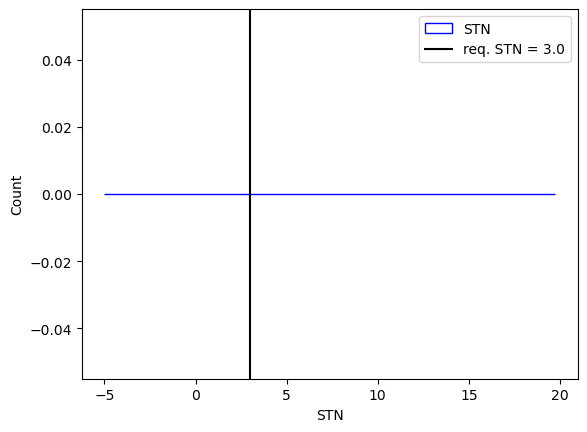

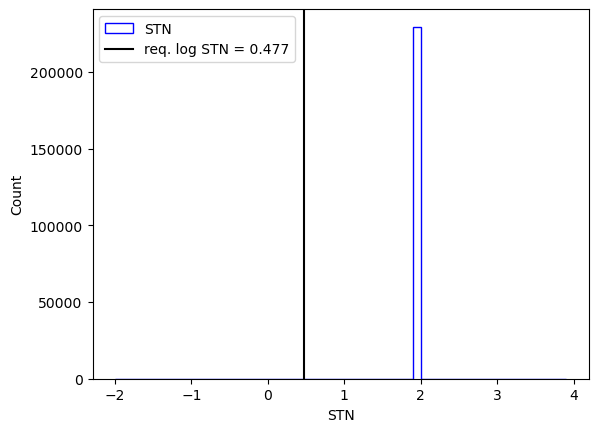

In [18]:
bins = np.arange(-5, 20, 0.25)
logbins = np.arange(-2, 4, 0.1)
df_calib = df[np.logical_and(df['qmag'] >= calib_mag_range[0], df['qmag'] < calib_mag_range[1])].reset_index(drop=True)

plt.figure()
plt.hist((df_calib['stn']), bins=bins, histtype='step', color='b', label='STN')
plt.axvline(calib_stn_req, color='k', label=f"req. STN = {calib_stn_req:.1f}")
plt.legend()
plt.xlabel("STN")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(np.log10(df_calib['stn']), bins=logbins, histtype='step', color='b', label='STN')
plt.axvline(np.log10(calib_stn_req), color='k', label=f"req. log STN = {np.log10(calib_stn_req):.3f}")
plt.legend()
plt.xlabel("STN")
plt.ylabel("Count")
plt.show()



In [19]:
# x = np.ones(1000) * 10
# t = np.linspace(1, 7, len(x))

# # generate lognormal scatter
# dx = np.random.lognormal(0, 1, 1000)

# plt.figure()
# plt.scatter(t, x, s=1)
# plt.scatter(t, x * dx, s=1)
# plt.yscale('log')
# plt.show()

# # make log histogram
# plt.figure()
# plt.hist(x*dx, bins=100, histtype='step', )
# plt.xscale('log')
# plt.show()

In [20]:

# Indices of records that have spectra
spec_inds = np.where([hasattr(el, '__len__') for el in df['s2'].values ])[0]

# Indices of calibration records that have spectra
df_calib_inds = np.where([hasattr(el, '__len__') for el in df_calib['s2'].values ])[0]


# DataFrame containing all records of events greater than the largest 
# calibration event. These are the target events.
df_target_ev = df_ev[df_ev['qmag'] >= calib_mag_range[1]].reset_index(drop=True)

print(f"{len(df_target_ev):,.0f} target events with M >= {calib_mag_range[1]} ({len(df[df['qmag'] >= calib_mag_range[1]]):,.0f} records)")
print(f"{len(np.unique(df_calib['event_id'])):,.0f} calibration events with {calib_mag_range[0]} <= M < {calib_mag_range[1]} ({len(df_calib):,.0f} records)")


df_target_ev['dlogbeta'] = np.nan

# DataFrames with _ev suffix are grouped by event (i.e. one event per row)
# Otherwise, DataFrames have one row per record (station/event combination)

# loop over each target event
for nev in trange(len(df_target_ev), desc="Computing corrected logbeta"):

    # Store the entire row of the target event
    target_ev = df_target_ev.loc[nev]

    # Store a copy of the calibration event records DataFrame
    df_c = df_calib.copy()

    # Get all records in df relating to target event_id
    df_target = df[df['event_id'] == target_ev['event_id']].reset_index(drop=True)

    
    # Filter out calibration event records that:
    #   1) are too shallow or too deep
    #   2) don't share stations with the target event
    #   3) are too low signal-to-noise ratio
    keep_bool = np.all([
        df_c['qdep']>=target_ev['qdep']-calib_zmax, 
        df_c['qdep']<=target_ev['qdep']+calib_zmax,
        np.isin(df_c['stind'].values, target_ev['stind']),
        df_c['stn'] >= calib_stn_req,
        ], axis=0)
    df_c = df_c[keep_bool].reset_index(drop=True)
    
    # rough square filter to avoid computing distances for all calibration events (slightly faster)
    keep_bool = np.all([
        np.abs(df_c['qx']-target_ev['qx']) <= calib_rmax*1000,
        np.abs(df_c['qy']-target_ev['qy']) <= calib_rmax*1000,
    ], axis=0)
    df_c = df_c[keep_bool].reset_index(drop=True)

    # compute station-event distance 
    df_c['tdist'] = np.sqrt((target_ev['qx'] - df_c['qx'].values)**2 + (target_ev['qy'] - df_c['qy'].values)**2)

    # filter out calibration events that are too far from the target event
    df_c = df_c[df_c['tdist'] <= calib_rmax*1000].reset_index(drop=True)

    # simplify df_c by removing unnecessary columns
    df_c = df_c[['stname','stind', 'event_id', 'logbeta']]

    ncalib = len(np.unique(df_c['event_id'].values))

    # only compute dlogbeta if there are enough remaining calibration events
    if ncalib >= ncalib_min:
        df_target_pre = df_target.copy()
        df_target = pd.merge(df_target, df_c, how='inner', on='stind', suffixes=['_t','_c'])
        
        df_target['dlogbeta'] = df_target[f'logbeta_t'] - df_target[f'logbeta_c']
        # print(len(df_target) - np.sum(np.isnan(df_target['dlogbeta'])), len(df_target) - np.sum(np.isnan(df_target['dlogbeta'])))
        if len(df_target) - np.sum(np.isnan(df_target['dlogbeta'])) > ncalib_min:
            df_target_ev.at[nev,'dlogbeta'] = np.nanmedian(df_target['dlogbeta'])

print('loop finished')

# compute dlogbeta_corr for all target events, not just events in ds
df_target_ev = df_target_ev[~np.isnan(df_target_ev['dlogbeta'])].reset_index(drop=True)
df_target_ev['dlogbeta_corr'] = df_target_ev['dlogbeta'].values

# indices where dlogbeta was calculated
not_nan = ~np.isnan(df_target_ev['dlogbeta'])

edges = np.arange(1, 7.3, 0.1)
for i in range(len(edges)-1):
    inrange = np.logical_and(df_target_ev['qmag']>=edges[i], df_target_ev['qmag']<edges[i+1])
    keep = np.where(np.logical_and(inrange, not_nan))[0]
    if np.sum(keep) > 0:
        dlogbeta = df_target_ev['dlogbeta'].values[keep]
        df_target_ev.loc[keep, 'dlogbeta_corr'] -= np.nanmedian(dlogbeta)


# remove records with delsig==0
ds = df_target_ev[df_target_ev['delsig'] != 0].reset_index(drop=True)






9,924 target events with M >= 1.2 (448,974 records)
5,076 calibration events with 1.0 <= M < 1.2 (229,454 records)


Computing corrected logbeta: 100%|██████████| 9924/9924 [04:56<00:00, 33.43it/s]


loop finished


In [21]:
M0_syn = np.power(10, (1.5 * df_target_ev['qmag'].values + 9.1))
df_target_ev['fc'] = np.power((16/7.0) * ((df_target_ev['delsig'].values)/M0_syn), 1/3.0) * k * Vs

In [22]:
# df_out = df_target_ev[['event_id', 'qmag', 'qlon', 'qlat', 'qdep', 'delsig', 'dlogbeta', 'dlogbeta_corr']]
# # save df_out to text file
# df_out.to_csv('data/synthetic_catAAA.txt', sep=' ', index=False)

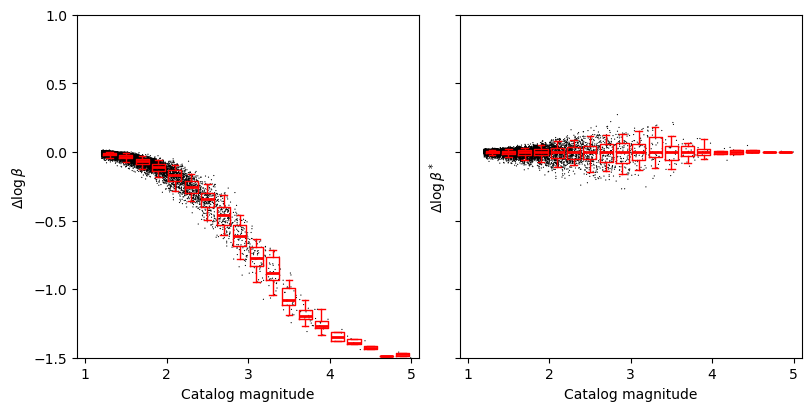

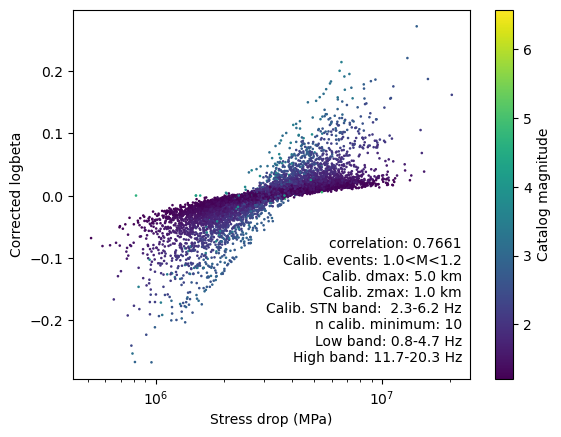

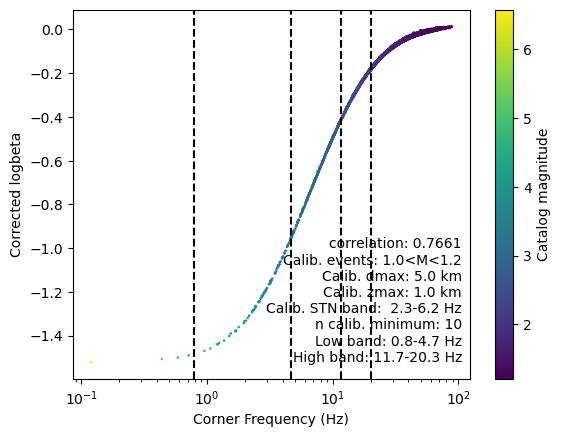

In [23]:

dx = 0.2
edges = np.arange(1.0, 7.3, dx)

corrcoef = np.corrcoef(np.log10(ds['delsig'].values.astype(float)), ds['dlogbeta_corr'].values)[0,1]

txt = '\n'.join([
    f"correlation: {corrcoef:.4f}", 
    f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
    f"Calib. dmax: {calib_rmax:.1f} km",
    f"Calib. zmax: {calib_zmax:.1f} km",
    f"Calib. STN band:  {stn_band[0]:.1f}-{stn_band[1]:.1f} Hz",
    f"n calib. minimum: {ncalib_min}",
    f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
    f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
])


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True, layout='constrained')
ax1.scatter(df_target_ev['qmag'], df_target_ev['dlogbeta'], c='k', s=3, marker='.', edgecolors='none')
ax2.scatter(df_target_ev['qmag'], df_target_ev['dlogbeta_corr'], c='k', s=3, marker='.', edgecolors='none')

boxplot(df_target_ev['qmag'], df_target_ev['dlogbeta'], xbins=edges, ax=ax1, color='r')
boxplot(df_target_ev['qmag'], df_target_ev['dlogbeta_corr'], xbins=edges, ax=ax2, color='r')

plt.xlim([0.9, 5.1])
plt.ylim([-1.5, 1])
ax1.set_xlabel('Catalog magnitude')
ax1.set_ylabel(r"$\Delta\log\beta$")
ax2.set_xlabel('Catalog magnitude')
ax2.set_ylabel(r"$\Delta\log\beta^*$")
# plt.savefig(f"figs/{phase}_logbeta_mag.pdf")
plt.show()

plt.figure()
ax = plt.gca()
sc = plt.scatter(df_target_ev['delsig'], df_target_ev['dlogbeta_corr'], c=df_target_ev['qmag'], s=3, marker='.')
# sc = plt.scatter(df_target_ev['delsig'], df_target_ev['dlogbeta'], c=df_target_ev['qmag'], s=3, marker='.')
plt.xscale('log')
# plt.ylim([-0.8, 0.8])
# plt.xlim([0.5, 5000.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Stress drop (MPa)')
plt.ylabel('Corrected logbeta')
# plt.title("All corrected logbeta results")
# add a colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Catalog magnitude')
# plt.savefig(f"figs/{phase}_delsig_correlation.pdf")
plt.show()

plt.figure()
ax = plt.gca()
sc = plt.scatter(df_target_ev['fc'], df_target_ev['dlogbeta'], c=df_target_ev['qmag'], s=3, marker='.')
plt.xscale('log')
# plt.ylim([-0.8, 0.8])
# plt.xlim([0.5, 5000.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
ax.axvline(low_beta_band[0], ls='--', c='k')
ax.axvline(low_beta_band[1], ls='--', c='k')
ax.axvline(high_beta_band[0], ls='--', c='k')
ax.axvline(high_beta_band[1], ls='--', c='k')
plt.xlabel('Corner Frequency (Hz)')
plt.ylabel('Corrected logbeta')
# plt.title("All corrected logbeta results")
# add a colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Catalog magnitude')
# plt.savefig(f"figs/{phase}_delsig_correlation.pdf")
plt.show()

In [49]:
np.round(8.654,1)

np.float64(8.7)

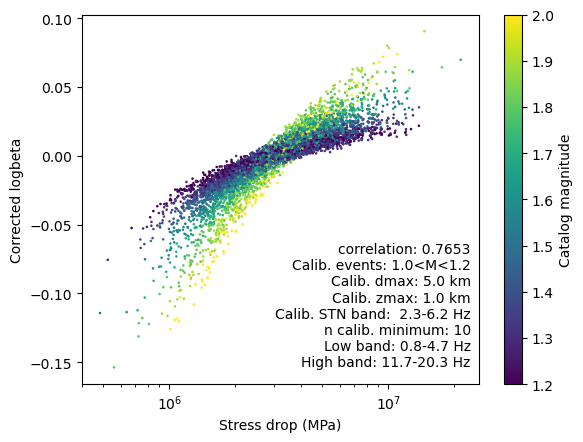

In [ ]:


plt.figure()
ax = plt.gca()
sc = plt.scatter(df_target_ev['delsig'][df_target_ev['qmag']<2], df_target_ev['dlogbeta_corr'][df_target_ev['qmag']<2], c=df_target_ev['qmag'][df_target_ev['qmag']<2], s=3, marker='.')
# sc = plt.scatter(df_target_ev['delsig'], df_target_ev['dlogbeta'], c=df_target_ev['qmag'], s=3, marker='.')
plt.xscale('log')
# plt.ylim([-0.8, 0.8])
# plt.xlim([0.5, 5000.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Stress drop (MPa)')
plt.ylabel('Corrected logbeta')
# plt.title("All corrected logbeta results")
# add a colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Catalog magnitude')
# plt.savefig(f"figs/{phase}_delsig_correlation.pdf")
plt.show()



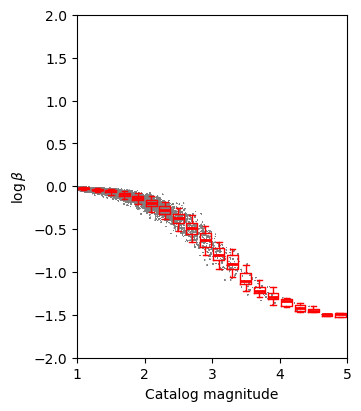

In [24]:
scatter_kwargs = {'s':1, 'marker':'.', 'edgecolors':'none'}

dx = 0.2
edges = np.arange(1.0, 7.3, dx)

plt.figure(figsize=(3.5,4), layout='constrained')
ax = plt.gca()
# ax.scatter(df['qmag'], df['logbeta'], c='k', s=3, marker='.', edgecolors='none')
# plt.boxplot(df['logbeta'].values, widths=0.5, sym='.', whis=(5, 95))
ax.scatter(df['qmag'], df['logbeta'], color='gray', **scatter_kwargs)
boxplot(df['qmag'], df['logbeta'], xbins=edges, ax=ax, color='r')
plt.xlim([1.0, 5.0])
plt.ylim([-2,2])
plt.xlabel('Catalog magnitude')
plt.ylabel(r'$\log\beta$')
# plt.savefig(f"figs/all_logbeta.png", bbox_inches='tight', dpi=600)
plt.show()

/Users/ivandevert/prog/mapping-tools/mapping_tools.py:84: RuntimeWarning: invalid value encountered in log10
  cticks = np.logspace(np.log10(clim[0]), np.log10(clim[1]), 5)


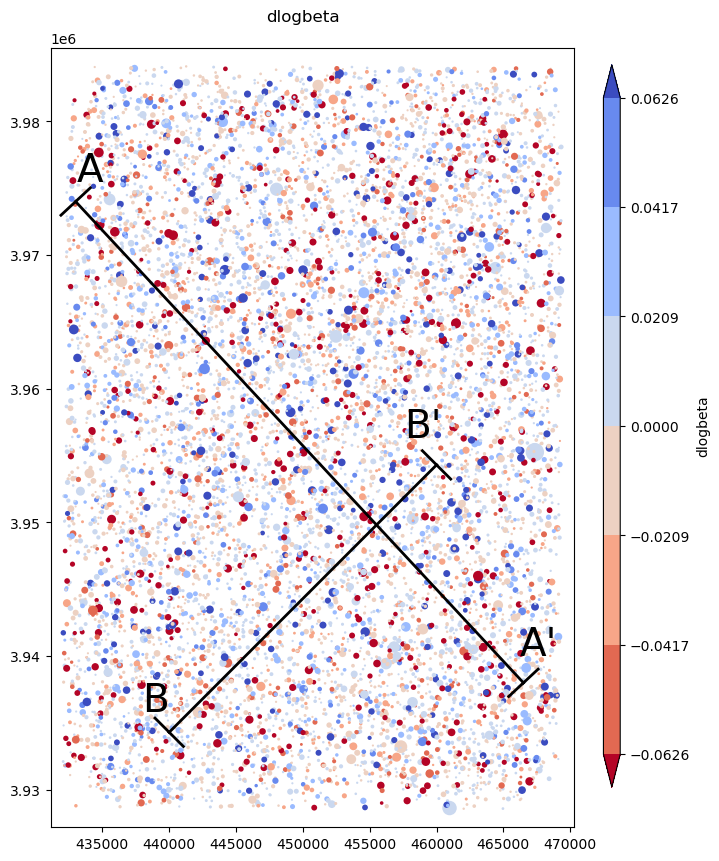

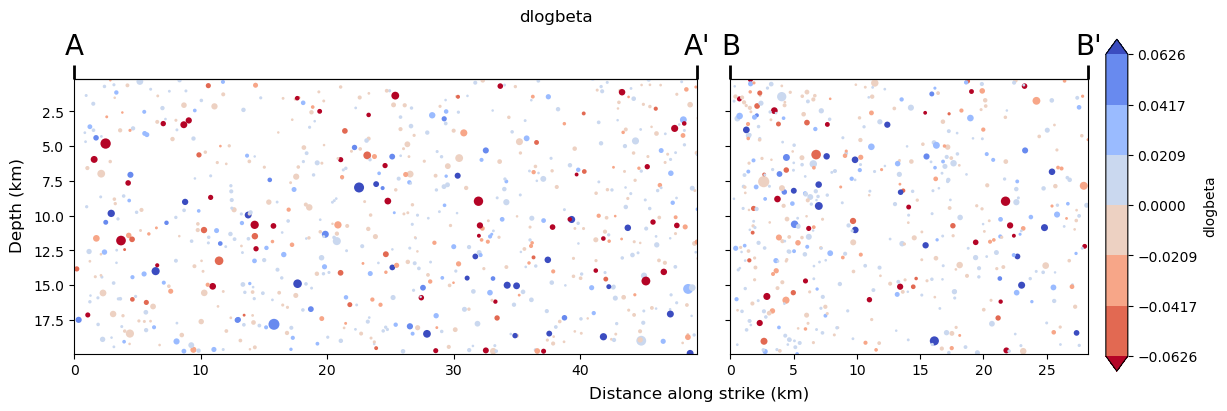

In [44]:

# compute widths of each cross section
A_len = np.sqrt(np.sum(np.power(Ap - A, 2)))
B_len = np.sqrt(np.sum(np.power(Bp - B, 2)))
A_ratio = A_len / (A_len + B_len)
B_ratio = B_len / (A_len + B_len)
gridspec_kw = {"width_ratios": [A_ratio, B_ratio]}

# plot the map-view and cross-sections of stress drop from Shearer et 
# al. (2022) for reference




df_plot = ds # [df_target_ev['qmag']>=2.0]
df_plot['easting'] = df_plot['qx']
df_plot['northing'] = df_plot['qy']
# df_plot = df_ev[np.logical_and(df_ev['qmag']>=1.6, df_ev['qmag']<1.8)]
# df_plot = df_ev[df_ev['qdep']<=1.0]
# df_plot = df_ev

dataname = 'dlogbeta_corr'
datatitle = r"dlogbeta"

cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='mediancenter')

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 8.5),
    layout='constrained')
mapout = mt.plot_map(
    df_plot,
    ax=ax,
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

mt.plot_xsection_line(A, Ap, ax, labels=["A", "A'"], linewidth=2, 
    exact_tick_length=xsec_dmax)
mt.plot_xsection_line(B, Bp, ax, labels=["B", "B'"], linewidth=2, 
    exact_tick_length=xsec_dmax)


cb_ax = fig.add_axes([1.0,.080,.028,.85])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
smap.set_clim([cnorm.vmin, cnorm.vmax])

cbar.ax.set_ylabel(datatitle)
fig.suptitle(datatitle)



fig, [ax1, ax2] = plt.subplots(nrows=1, ncols=2, figsize=(11, 4),
    sharey='all', sharex='col', gridspec_kw=gridspec_kw, layout='constrained')


importlib.reload(mt)
xsecoutA = mt.plot_xsection(
    df_plot, 
    p1 = A, 
    p2 = Ap, 
    max_dist = xsec_dmax,
    ax=ax1, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    )

xsecoutB = mt.plot_xsection(
    df_plot, 
    p1 = B, 
    p2 = Bp, 
    max_dist = xsec_dmax,
    ax=ax2, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    line_name="B"
    )


fig.supylabel("Depth (km)")
fig.supxlabel("Distance along strike (km)", x=0.63)
fig.suptitle(datatitle)

# colorbar
cb_ax = fig.add_axes([1.0,.085,.02,.83])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
# smap.set_clim(clim)
# cbar.ax.set_yticks(cticks)
# cbar.ax.set_yticklabels(clabels)
cbar.ax.set_ylabel(datatitle)

# fig.canvas.draw_idle()

plt.show()




In [45]:
# load both csvs
df_const = pd.read_csv('data/synthetic_cat.txt', sep=' ')
df_noise = pd.read_csv('data/synthetic_cat_noise.txt', sep=' ')

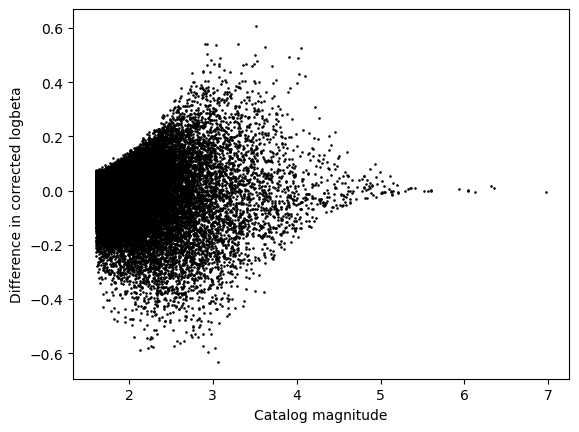

In [46]:
plt.figure()
plt.scatter(df_const['qmag'], df_noise['dlogbeta'] - df_const['dlogbeta'], c='k', s=3, marker='.')
plt.xlabel('Catalog magnitude')
plt.ylabel('Difference in corrected logbeta')
plt.show()